# Student–Student Opinion Network

In this network **each student is a point**, and **two students are joined by a line (an "edge") when they agree with each other more than expected by chance**. The stronger the agreement, the heavier the edge.

We use it to answer:
* Which students are at the centre of class opinion, and which are on the periphery?
* Does the answer change from topic to topic (Technology, Education, Society, Environment)?

**Steps**
1. Clean the survey and turn answers into numbers (shared file `clean.py`).
2. Give every pair of students an agreement score.
3. Adjust that score for agreement that happens just by chance. This is the score we use.
4. Remove weak edges step by step to see how the network holds together.
5. Measure the network: how many edges each student has, how close students are to each other, and who is central.

# Dataset Preparation

* **Missing answers:** blank cells and "No Comments" count as missing.
* **Removed students:** only the 5 responses that were **completely empty**. Students who skipped whole sections are **kept**: 4 answered only Technology, and 1 skipped all of Environment. We compare two students only on the questions both of them answered.
* **Answers as numbers:** Strongly Disagree = −2, Disagree = −1, Neutral = 0, Agree = +1, Strongly Agree = +2. A plus sign means agree and a minus sign means disagree; the size shows how strongly. (Adding 3 gives the usual 1–5 scale.)

In [1]:
import itertools
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

from clean import load_survey, SECTIONS

responses, statements, log = load_survey(verbose=True)
students = list(responses.index)
questions = list(responses.columns)
X = responses.to_numpy()
N, M = X.shape

PLOTS = Path("student_plots")
PLOTS.mkdir(exist_ok=True)

Raw: 96 students x 60 statements
Raw answer counts: {'Strongly Agree': 2251, 'Agree': 1914, 'Neutral': 686, '<blank>': 505, 'Disagree': 256, 'Strongly Disagree': 111, 'No Comments': 37}
Dropped 5 completely empty responses: ['44', '60', '68', '73', '78']
Kept 91 students, 242 missing answers remain
Students with missing answers: {'30': 45, '39': 45, '77': 45, '87': 45, '79': 15, '123': 10, '120': 4, '92': 4, '125': 4, '42': 3, '81': 3, '24': 3, '102': 2, '103': 2, '40': 2, '95': 2, '93': 2, '12': 1, '19': 1, '32': 1, '69': 1, '84': 1, '118': 1}


In [2]:
# Plot styling: one quiet style for every figure in the report
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, AQUA, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#b5b3ab"
LIKERT_COLORS = ["#c23b3a", "#ec9a99", "#e1e0d9", "#86b6ef", "#1c5cab"]  # SD, D, N, A, SA (diverging red-gray-blue)
LIKERT_LABELS = ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"]
seq = matplotlib.colors.LinearSegmentedColormap.from_list("seq", ["#f0efec", "#86b6ef", "#1c5cab", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.titlesize": 12, "axes.labelsize": 10, "legend.frameon": False,
    "lines.linewidth": 2, "font.size": 10,
})

def save(fig, name):
    fig.savefig(PLOTS / name, dpi=300, bbox_inches="tight")

In [3]:
# Share of each answer after cleaning, and who still has gaps
answer_mix = pd.Series(X[~np.isnan(X)]).value_counts().sort_index()
answer_mix.index = LIKERT_LABELS
print((answer_mix / answer_mix.sum()).round(3).to_string())
print()
print("Students with some missing answers (all kept):")
print(pd.Series(log["missing_per_student"], name="missing").to_frame().T.to_string())

Strongly Disagree    0.021
Disagree             0.049
Neutral              0.131
Agree                0.367
Strongly Agree       0.431

Students with some missing answers (all kept):
         30  39  77  87  79  123  120  92  125  42  81  24  102  103  40  95  93  12  19  32  69  84  118
missing  45  45  45  45  15   10    4   4    4   3   3   3    2    2   2   2   2   1   1   1   1   1    1


- Most answers are positive: about 72% are Agree or Strongly Agree, and only about 7% are Disagree or Strongly Disagree. 
- If nearly everyone agrees with nearly everything, *any* two students will look alike, so simply counting matching answers can't tell us who really thinks alike.

# Constructing the Network

## Step 1: Simple agreement score

For each question that **both** students answered, the pair gets:

| Their two answers | Points |
|---|---|
| Exactly the same (including both Neutral) | 2 |
| Different, but on the same side (Agree and Strongly Agree, or Disagree and Strongly Disagree) | 1 |
| Anything else (opposite sides, or Neutral against a non-neutral answer) | 0 |

The **simple agreement score** of a pair is their average points per shared question, halved so it runs from 0 (never agree) to 1 (identical answers):

$$w^{simple}_{ij} = \frac{1}{2\,n_{ij}} \sum_{q \in \text{shared}} s_q(i,j)$$

We average instead of adding up. For students who answered only one section share just 15 questions with everyone, so a total would make them look less similar than they are.

In [4]:
def pair_scores(x):
    '''Score matrix s_q(i,j) for one question; NaN where either student did not answer.'''
    same = x[:, None] == x[None, :]
    same_polarity = (np.sign(x)[:, None] == np.sign(x)[None, :]) & (x[:, None] != 0)
    s = np.where(same, 2.0, np.where(same_polarity, 1.0, 0.0))
    answered = ~np.isnan(x)
    s[~(answered[:, None] & answered[None, :])] = np.nan
    return s


def agreement_weights(X):
    '''Return (simple scores, adjusted scores, average points per question for a random pair).'''
    n, m = X.shape
    off_diag = ~np.eye(n, dtype=bool)
    raw_sum = np.zeros((n, n))
    excess_sum = np.zeros((n, n))
    shared = np.zeros((n, n))
    expected = np.zeros(m)
    for q in range(m):
        s = pair_scores(X[:, q])
        both = ~np.isnan(s)
        # Expected score for two different classmates picked at random on this question
        expected[q] = s[both & off_diag].mean()
        raw_sum += np.where(both, s, 0)
        excess_sum += np.where(both, s - expected[q], 0)
        shared += both
    with np.errstate(invalid="ignore", divide="ignore"):
        raw = raw_sum / (2 * shared)
        corrected = excess_sum / shared
    np.fill_diagonal(raw, 0)
    np.fill_diagonal(corrected, 0)
    return np.nan_to_num(raw), np.nan_to_num(corrected), expected


W_raw, W_cc, expected = agreement_weights(X)
iu = np.triu_indices(N, 1)

raw_pairs = W_raw[iu]
print(f"Raw weights over {len(raw_pairs)} pairs: min {raw_pairs.min():.3f}, median {np.median(raw_pairs):.3f}, max {raw_pairs.max():.3f}")
print(f"Pairs with raw weight 0: {(raw_pairs == 0).sum()}  ->  the raw graph is complete")

Raw weights over 4095 pairs: min 0.133, median 0.542, max 0.850
Pairs with raw weight 0: 0  ->  the raw graph is complete


## Step 2: Adjusting for chance

**The problem.**
- No pair of students has a simple score of 0, so **every student is linked to every other student** (Complete Graph).
- The reason is that when most students pick Agree or Strongly Agree on most questions, two students picked **at random** still have the same kind of opinion most of the time.

So a high simple score says that *"both students agree with most statements"*, (true of almost everyone). It doesn't say *"these two think alike"*. This causes two problems:
1. There's no natural place to cut off weak edges; any cutoff would be arbitrary.
2. Every match counts the same. A match on a controversial question tells us a lot about two people; a match on a question where 90% said Strongly Agree tells us almost little.

**The fix.**
1. For each question $q$, work out the $E_q$ = **average points over every pair of students**. That's how many points two students picked at random would get on that question on average.
2. A pair's **adjusted agreement score** is how far above that average they are, averaged over their shared questions:

$$w_{ij} = \frac{1}{n_{ij}} \sum_{q \in \text{shared}} \big(s_q(i,j) - E_q\big)$$

How to read it:
* **Above 0:** the pair agrees **more** than two random classmates would. We draw an edge.
* **About 0:** they agree about as much as chance.
* **Below 0:** they agree **less** than chance, i.e. they tend to disagree.
* A question almost everyone agrees on has a high $E_q$, so matching on it adds almost nothing. A question that splits the class has a low $E_q$, so matching on it adds a lot.
* The cutoff "above 0" now has a clear meaning, *more than chance*, so it isn't an arbitrary number.

From here on, "score" means this adjusted score unless we say otherwise.

Questions that split the class most (lowest points for a random pair):
  E02  E=0.58  Traditional written examinations accurately measure a student's knowledge.
  T08  E=0.58  AI-assisted diagnosis should become routine in healthcare.
  E04  E=0.63  High-quality online learning can effectively complement classroom teaching.
  T09  E=0.64  Autonomous vehicles will ultimately make transportation safer.
  E13  E=0.72  Universities should invest more resources in research than in expanding infrastructure.
Questions the class agrees on most (highest points for a random pair):
  E15  E=1.55  Continuous learning and skill development are essential throughout one's career.
  V13  E=1.52  Companies should be held accountable for the environmental impacts of their activities.
  S05  E=1.43  Individuals should have greater control over how their personal data are collected and used.
  E11  E=1.43  University curricula should be updated more frequently to match emerging technologies.
  V09  E=1.43

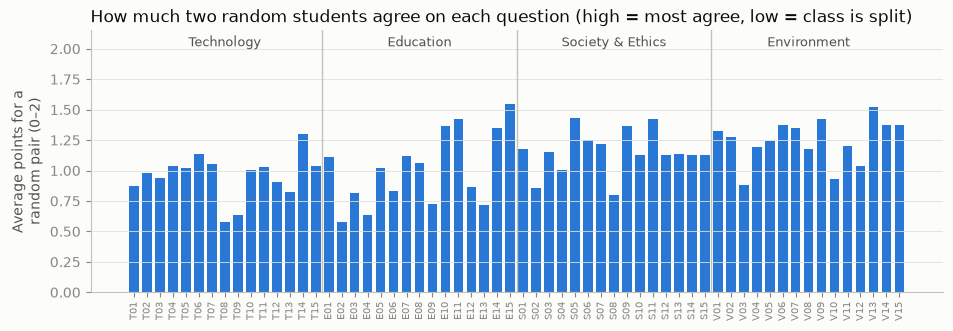

In [5]:
order = np.argsort(expected)
print("Questions that split the class most (lowest points for a random pair):")
for q in order[:5]:
    print(f"  {questions[q]}  E={expected[q]:.2f}  {statements[questions[q]]}")
print("Questions the class agrees on most (highest points for a random pair):")
for q in order[-5:][::-1]:
    print(f"  {questions[q]}  E={expected[q]:.2f}  {statements[questions[q]]}")

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(range(M), expected, color=BLUE, width=0.75)
ax.set_xticks(range(M), questions, rotation=90, fontsize=7)
for b in (15, 30, 45):
    ax.axvline(b - 0.5, color=AXIS, lw=1)
for k, (code_, name) in enumerate(SECTIONS.items()):
    ax.text(7 + 15 * k, 2.02, name, ha="center", color=INK2, fontsize=9)
ax.set_ylim(0, 2.15)
ax.set_ylabel("Average points for a\nrandom pair (0–2)")
ax.set_title("How much two random students agree on each question (high = most agree, low = class is split)", loc="left")
ax.grid(axis="x", visible=False)
save(fig, "expected_score_per_question.png")
plt.show()

The two histograms below show why the adjustment matters: where the simple score puts every pair, and where the adjusted score puts them once chance agreement is taken out.

Adjusted scores: min -0.728, median -0.008, max 0.709
Share of pairs that agree more than chance (score > 0): 0.495


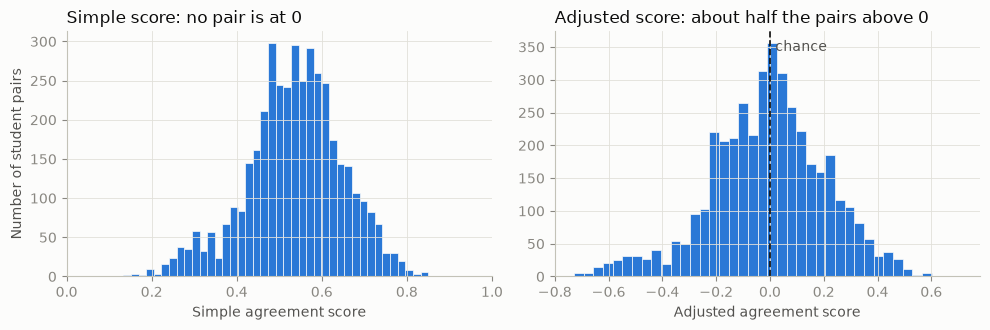

In [6]:
cc_pairs = W_cc[iu]
print(f"Adjusted scores: min {cc_pairs.min():.3f}, median {np.median(cc_pairs):.3f}, max {cc_pairs.max():.3f}")
print(f"Share of pairs that agree more than chance (score > 0): {(cc_pairs > 0).mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(raw_pairs, bins=40, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
axes[0].set_title("Simple score: no pair is at 0", loc="left")
axes[0].set_xlabel("Simple agreement score")
axes[0].set_ylabel("Number of student pairs")
axes[0].set_xlim(0, 1)
axes[1].hist(cc_pairs, bins=40, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
axes[1].axvline(0, color=INK, lw=1.2, ls="--")
axes[1].text(0.02, axes[1].get_ylim()[1] * 0.92, "chance", color=INK2)
axes[1].set_title("Adjusted score: about half the pairs above 0", loc="left")
axes[1].set_xlabel("Adjusted agreement score")
fig.tight_layout()
save(fig, "weight_distributions.png")
plt.show()

After adjusting, about half the pairs agree more than chance and half agree less. **Our network links every pair with an adjusted score above 0.** That's 2026 edges, about half of all possible pairs. The graph is still dense because there are $O(n^2)$ edges.

# Sparsification of the network


Our network links about **half of all possible pairs** (2026 edges between 91 students). That is far too dense to draw. So we thin it out, two ways, each answering a different question.

1. **Remove the weakest edges everywhere** (one cutoff for the whole network). Tells us how the class holds together as we demand stronger and stronger agreement, and who drops out first.
2. **Keep each student's two strongest edges.** Judges each edge against that student's own edges, so a student whose agreement is weak across the board still keeps their best ones. Small enough to draw, and it is the sparse version we measure alongside the full network in the next section.

Both work on the same adjusted scores; they differ only in which edges they keep.


## 1. Removing the weakest edges everywhere

We start with every pair linked, then remove the weakest edges a bit at a time and watch three things:
* **Size of the biggest connected group:** is the class still one connected whole?
* **Students left with no edges:** who has no strong edge to anyone?
* **Clustering:** do a student's neighbours tend to be linked to each other?

We do this for both the simple and the adjusted score. So the two are compared fairly, the x-axis is the **share of pairs whose edge has been removed**, not the score itself. On the adjusted score, the "above chance" cutoff we use falls at about 51% removed.

In [7]:
def build_graph(W, threshold=0.0, nodes=students):
    '''Graph keeping edges with weight strictly above threshold.'''
    G = nx.Graph()
    G.add_nodes_from(nodes)
    idx = np.triu_indices(len(nodes), 1)
    keep = W[idx] > threshold
    G.add_weighted_edges_from(
        (nodes[a], nodes[b], W[a, b]) for a, b in zip(idx[0][keep], idx[1][keep])
    )
    return G


def sweep(W, fractions):
    pairs = W[iu]
    rows = []
    for f in fractions:
        t = np.quantile(pairs, f) if f > 0 else pairs.min() - 1
        G = build_graph(W, t)
        comps = [len(c) for c in nx.connected_components(G)]
        rows.append({
            "removed": f, "threshold": t, "edges": G.number_of_edges(),
            "largest_component": max(comps), "isolated": sum(c == 1 for c in comps),
            "clustering": nx.average_clustering(G),
        })
    return pd.DataFrame(rows)


fractions = np.round(np.arange(0, 0.981, 0.02), 2)
sweep_raw = sweep(W_raw, fractions)
sweep_cc = sweep(W_cc, fractions)

chance_fraction = (cc_pairs <= 0).mean()
print(f"The chance cutoff (adjusted score = 0) removes {chance_fraction:.0%} of pairs")

# every 10th step plus the final one, so the table covers the same range as the charts below
shown = list(range(0, len(sweep_cc), 5))
if shown[-1] != len(sweep_cc) - 1:
    shown.append(len(sweep_cc) - 1)
sweep_cc.iloc[shown].set_index("removed").round(3)

The chance cutoff (adjusted score = 0) removes 51% of pairs


,threshold,edges,largest_component,isolated,clustering
removed,,,,,
0.00,-1.728,4095,91,0,1.000
0.10,-0.275,3683,91,0,0.942
0.20,-0.172,3274,91,0,0.879
0.30,-0.109,2865,91,0,0.831
0.40,-0.048,2456,90,1,0.793
0.50,-0.008,2047,90,1,0.734
0.60,0.042,1634,89,2,0.670
0.70,0.091,1227,87,4,0.598
0.80,0.173,818,82,9,0.525


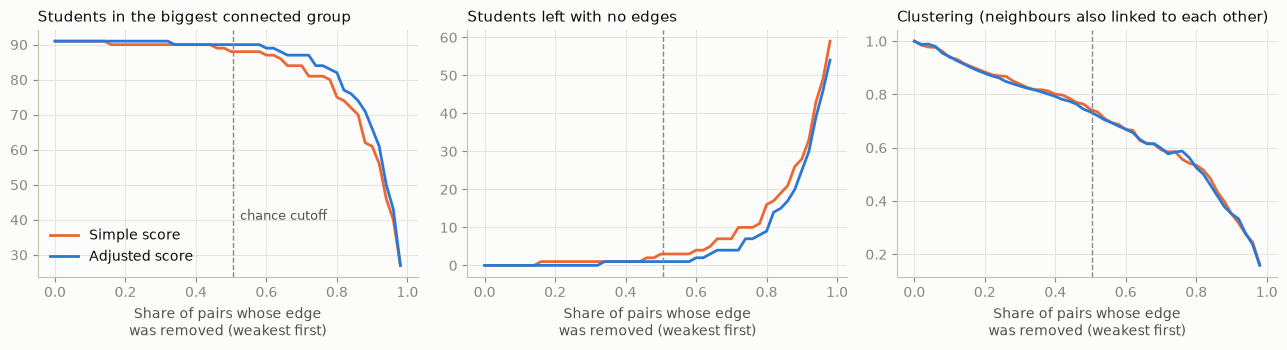

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
panels = [("largest_component", "Students in the biggest connected group"),
          ("isolated", "Students left with no edges"),
          ("clustering", "Clustering (neighbours also linked to each other)")]
for ax, (col, title) in zip(axes, panels):
    ax.plot(sweep_raw["removed"], sweep_raw[col], color=ORANGE, label="Simple score")
    ax.plot(sweep_cc["removed"], sweep_cc[col], color=BLUE, label="Adjusted score")
    ax.axvline(chance_fraction, color=MUTED, lw=1, ls="--")
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_xlabel("Share of pairs whose edge\nwas removed (weakest first)")
axes[0].text(chance_fraction + 0.02, 40, "chance cutoff", color=INK2, fontsize=9)
axes[0].legend(loc="lower left")
fig.tight_layout()
save(fig, "threshold_sweep.png")
plt.show()

A student is cut off from the network once their strongest edge is removed, so the weakest "strongest edge" tells us who goes first. Their average answer is shown next to it, to see whether the students who drop off early are the ones who agree less with the class as a whole.

In [9]:
# Who loses all edges first? A student is cut off once their strongest edge is removed.
strongest_tie = pd.Series(W_cc.max(axis=1), index=students).sort_values()
mean_answer = responses.mean(axis=1)
print("Students whose strongest edge is weakest (first to be cut off):")
print(pd.DataFrame({"strongest_edge": strongest_tie, "mean_answer": mean_answer})
      .loc[strongest_tie.index[:8]].round(2).to_string())

Students whose strongest edge is weakest (first to be cut off):
     strongest_edge  mean_answer
120            0.00        -0.21
89             0.04         0.82
63             0.06         1.12
22             0.07         0.73
125            0.11         0.73
36             0.11         0.90
119            0.11         0.27
17             0.16         0.98


**What this shows.**
* **No sudden break-up.** Neither line shows the biggest group suddenly falling apart. Students drop off one or a few at a time. So the class isn't made of tight camps held together by a few weak links; opinions are spread out fairly evenly.
* **The first to drop off are the students who agree least with others.** Student 120 has no above-chance edge with anyone, so they are cut off as soon as we use the chance cutoff. Next are 89, 63, 22, 125 and 119. Most of them have average answers well below the class average of +1.14, meaning they answered Neutral or Disagree more often than their classmates.
* **At the same number of edges, the adjusted score keeps more students connected** than the simple score, and its clustering is very slightly lower. Both scores behave similarly overall.
* **The network we analyse** is the adjusted score with every edge above 0. The cutoff has a clear meaning ("more than chance"), 90 of 91 students stay connected.

## 2. Keeping each student's two strongest edges

Before the second experiment, here is the network itself: every pair whose adjusted score is above 0.

In [10]:
G = build_graph(W_cc, 0.0)   # the network we analyse: every pair that agrees more than chance
print(f"{G.number_of_nodes()} students, {G.number_of_edges()} edges, {nx.density(G):.1%} of all pairs linked")

91 students, 2026 edges, 49.5% of all pairs linked


**Every student keeps only their two strongest edges.** An edge survives if it is in the top two of *either* of its students. A student with many edges that rank top-2 with its neigbors will have >2 edges.

This is the version we draw, and the second version we measure in the next section. It is small enough to read, and because each student keeps their own best edges, nobody is cut off just for agreeing weakly with everyone.

In [11]:
def strongest_edges(G, k=2):
    """Keep each student's k strongest edges (an edge survives if either student ranks it in their top k)."""
    H = nx.Graph()
    H.add_nodes_from(G)
    for u in G:
        strongest = sorted(G[u].items(), key=lambda item: -item[1]["weight"])[:k]
        H.add_edges_from((u, v, d) for v, d in strongest)
    return H


T = strongest_edges(G, 2)
components = sorted((len(c) for c in nx.connected_components(T)), reverse=True)
degrees = pd.Series(dict(T.degree()))
print(f"Edges kept: {T.number_of_edges()} of {G.number_of_edges()} ({nx.density(T):.1%} of all pairs)")
print(f"Component sizes: {components}")
print(f"Edges per student: {degrees.min()} to {degrees.max()}, average {degrees.mean():.1f}")
print("Students chosen most often by others:")
print(degrees.sort_values(ascending=False).head(6).to_frame("edges")
      .join(responses.mean(axis=1).rename("average answer")).round(2).to_string())

Edges kept: 155 of 2026 (3.8% of all pairs)
Component sizes: [90, 1]
Edges per student: 0 to 12, average 3.4
Students chosen most often by others:
     edges  average answer
87      12            1.20
41      11            1.77
110     10            1.68
94       9            1.75
81       8            1.53
67       8            1.47


Even at two edges each, 90 of the 91 students are still joined into one piece; only student 120, who has no above-chance edge at all, stands apart. The students picked most often as someone's strongest match are the positive answerers (41, 110, 94, 67, 81), plus 87, whose 15 answers make their scores unreliable.

In the drawing, students are placed by a spring layout, which pulls students joined by an edge together and pushes the rest apart. A dot's size is the student's total agreement (strength) **in the full network**, and its colour is that student's average answer, so we can see whether position lines up with how emphatically someone answered. The four labelled students are the first to be cut off in experiment 1.

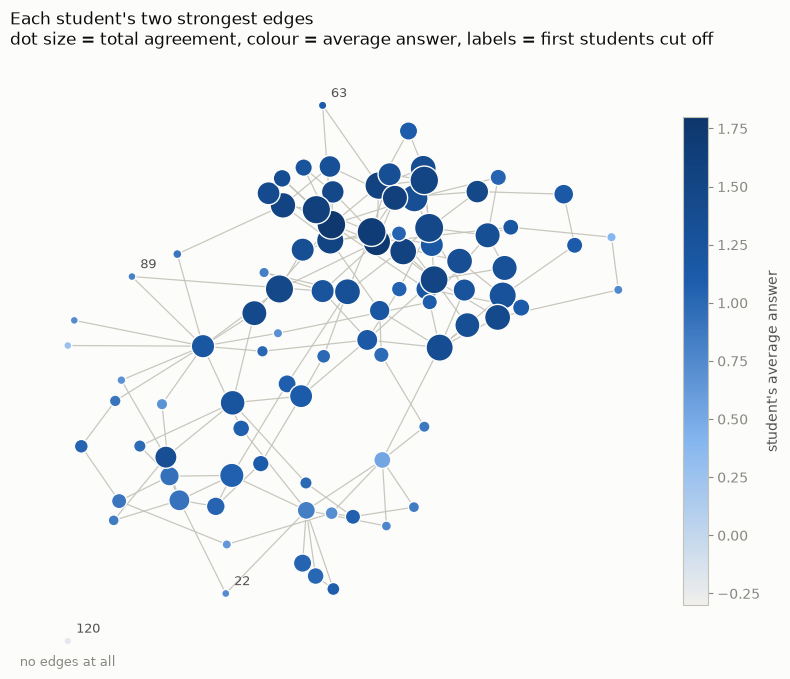

In [12]:
# Unweighted spring layout: the surviving edges are already the strongest ones,
# and the score values are too small to steer the layout usefully.
# Students with no edges are laid out separately, otherwise they are flung far
# from the rest and squash everything else into a corner.
connected = [s for s in T if T.degree(s) > 0]
alone = [s for s in T if T.degree(s) == 0]
pos = nx.spring_layout(T.subgraph(connected), seed=7, k=0.3, iterations=500)
span = np.ptp([p[0] for p in pos.values()])
for j, s in enumerate(alone):
    pos[s] = (min(p[0] for p in pos.values()) + j * 0.1 * span,
              min(p[1] for p in pos.values()) - 0.12 * span)
strength = pd.Series(dict(G.degree(weight="weight")))
mean_answer = responses.mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 8))
nx.draw_networkx_edges(T, pos, ax=ax, edge_color=AXIS, width=0.9, alpha=0.9)
nodes = nx.draw_networkx_nodes(
    T, pos, ax=ax, node_color=[mean_answer[s] for s in T.nodes], cmap=seq,
    vmin=-0.3, vmax=1.8, node_size=[30 + 25 * max(strength[s], 0) for s in T.nodes],
    edgecolors=SURFACE, linewidths=1)
for s in strongest_tie.index[:4]:
    x, y = pos[s]
    ax.annotate(s, (x, y), xytext=(6, 6), textcoords="offset points", color=INK2, fontsize=9)
fig.colorbar(nodes, ax=ax, fraction=0.035, pad=0.01, label="student's average answer")
if alone:
    x, y = pos[alone[0]]
    ax.annotate("no edges at all", (x, y), xytext=(0, -18), textcoords="offset points",
                ha="center", color=MUTED, fontsize=9)
ax.set_title("Each student's two strongest edges\n"
             "dot size = total agreement, colour = average answer, labels = first students cut off",
             loc="left")
ax.axis("off")
save(fig, "network_drawing.png")
plt.show()

# Analysis

## Network measurements: edges, clustering, path length, small-world

We measure both versions of the network:
* **Full network:** every pair that agrees more than chance. About half of all pairs are linked, so it's very crowded.
* **Top-2 network:** each student's two strongest edges, from the sparsification section. Only 3.8% of pairs are linked. In a network as crowded as the full one, almost everyone is within 2 steps of everyone, so distances say more in the sparse version.

Each is compared with an **ER graph** (Erdős–Rényi): the same 91 students and the same number of edges as the network it is compared with, but every edge placed between a randomly chosen pair. We build **20 such graphs** and average their measurements, so a single unlucky draw doesn't decide the comparison. This tells us what each measurement would look like if only the number of edges mattered.

What each row of the table means:
* **Degree** (mean, spread, max): how many edges students have.
* **Average clustering:** for each student, the share of their neighbours who are also linked to each other, averaged over students. **Transitivity** is the same idea counted over the whole network at once.
* **Average shortest path:** the average number of steps between two students. **Diameter:** the largest such distance. The **weighted** version counts a strong edge as a short step (step length = 1/score).
* **Global efficiency:** the average of 1 / (steps between two students). Like path length, but it still works when some students aren't connected at all (they count as 0).
* **Small-world σ:** (clustering ÷ random clustering) ÷ (path length ÷ random path length), from Humphries & Gurney (2008). **Above 1** means students are much more clustered than random while still being about as close to each other as random: the "small-world" pattern.
* **Degree assortativity:** do students with many edges mainly link to other students with many edges (positive), to students with few (negative), or neither (about 0)?

In [13]:
Gc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
for H in (G, T):
    for u, v, d in H.edges(data=True):
        d["distance"] = 1 / d["weight"]   # strong agreement = short step


def largest_component(H):
    return H.subgraph(max(nx.connected_components(H), key=len)).copy()


def structure(H, weighted=True):
    L = largest_component(H)
    k = np.array([d for _, d in H.degree()])
    row = {
        "nodes": H.number_of_nodes(), "edges": H.number_of_edges(), "density": nx.density(H),
        "isolated": nx.number_of_isolates(H), "largest component": L.number_of_nodes(),
        "mean degree": k.mean(), "degree std": k.std(), "max degree": k.max(),
        "average clustering": nx.average_clustering(H), "transitivity": nx.transitivity(H),
        "avg shortest path": nx.average_shortest_path_length(L), "diameter": nx.diameter(L),
        "global efficiency": nx.global_efficiency(H),
        "degree assortativity": nx.degree_assortativity_coefficient(H),
    }
    if weighted:
        row["weighted avg path (1/w)"] = nx.average_shortest_path_length(L, weight="distance")
    return row


def er_reference(H, samples=20):
    """Average each measurement over `samples` ER graphs with H's node and edge count."""
    rows = [structure(nx.gnm_random_graph(H.number_of_nodes(), H.number_of_edges(), seed=s), weighted=False)
            for s in range(samples)]
    return pd.DataFrame(rows).mean()


table = pd.DataFrame({"Full network": structure(G), "Random (full)": er_reference(G),
                      "Top-2 network": structure(T), "Random (top-2)": er_reference(T)})
for real, ref in [("Full network", "Random (full)"), ("Top-2 network", "Random (top-2)")]:
    table.loc["small-world sigma", real] = (
        (table.loc["average clustering", real] / table.loc["average clustering", ref])
        / (table.loc["avg shortest path", real] / table.loc["avg shortest path", ref]))
order = ["nodes", "edges", "density", "isolated", "largest component", "mean degree", "degree std", "max degree",
         "average clustering", "transitivity", "avg shortest path", "weighted avg path (1/w)", "diameter",
         "global efficiency", "small-world sigma", "degree assortativity"]
structure_table = table.loc[order]
structure_table.round(3)

,Full network,Random (full),Top-2 network,Random (top-2)
nodes,91.000,91.000,91.000,91.000
edges,2026.000,2026.000,155.000,155.000
density,0.495,0.495,0.038,0.038
isolated,1.000,0.000,1.000,2.750
largest component,90.000,91.000,90.000,87.550
mean degree,44.527,44.527,3.407,3.407
degree std,20.999,4.589,2.234,1.800
max degree,71.000,56.350,12.000,8.500
average clustering,0.730,0.494,0.154,0.026
transitivity,0.757,0.494,0.090,0.031


Three charts from those numbers:

* **Left and middle:** how many edges each student has, in the full and the top-2 network, with the curve an ER graph of the same size would produce. If our bars are wider than the curve, students differ more in how many classmates they agree with than chance would explain.
* **Right:** how many steps apart two students are in the top-2 network, next to the same thing averaged over 10 ER graphs with that same number of edges. It shows whether the distances come from the number of edges alone.

The cell also checks whether a student's clustering depends on how many edges they have.

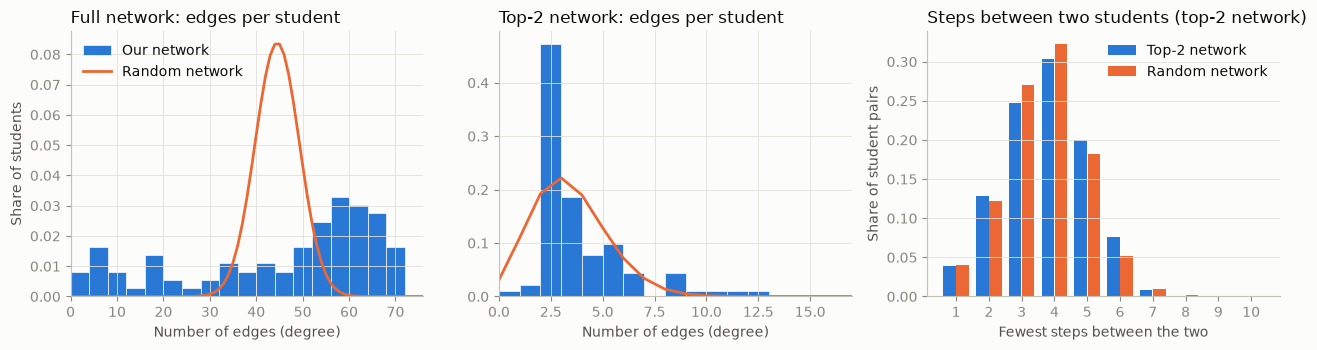

Correlation between number of edges and clustering: 0.11 (main graph)


In [14]:
from scipy.stats import binom

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, H, title in [(axes[0], G, "Full network: edges per student"), (axes[1], T, "Top-2 network: edges per student")]:
    k = np.array([d for _, d in H.degree()])
    n, p = H.number_of_nodes(), nx.density(H)
    bins = np.arange(0, k.max() + 5, 4 if H is G else 1)
    ax.hist(k, bins=bins, density=True, color=BLUE, edgecolor=SURFACE, linewidth=0.5, label="Our network")
    ks = np.arange(0, n)
    ax.plot(ks, binom.pmf(ks, n - 1, p), color=ORANGE, label="Random network")
    ax.set_xlim(0, k.max() + 5)
    ax.set_title(title, loc="left")
    ax.set_xlabel("Number of edges (degree)")
axes[0].set_ylabel("Share of students")
axes[0].legend(loc="upper left")

# Distance distribution in the top-2 network vs ER
ax = axes[2]
Lb = largest_component(T)
lengths = [d for src, dd in nx.shortest_path_length(Lb) for dst, d in dd.items() if src < dst]
er_lengths = []
for s in range(10):   # 10 ER graphs with the same node and edge count
    Le = largest_component(nx.gnm_random_graph(T.number_of_nodes(), T.number_of_edges(), seed=s))
    er_lengths += [d for src, dd in nx.shortest_path_length(Le) for dst, d in dd.items() if src < dst]
vals = np.arange(1, max(max(lengths), max(er_lengths)) + 1)
obs = pd.Series(lengths).value_counts(normalize=True).reindex(vals, fill_value=0)
ref = pd.Series(er_lengths).value_counts(normalize=True).reindex(vals, fill_value=0)
ax.bar(vals - 0.2, obs, width=0.38, color=BLUE, label="Top-2 network")
ax.bar(vals + 0.2, ref, width=0.38, color=ORANGE, label="Random network")
ax.set_xticks(vals)
ax.set_title("Steps between two students (top-2 network)", loc="left")
ax.set_xlabel("Fewest steps between the two")
ax.set_ylabel("Share of student pairs")
ax.legend(loc="upper right")
ax.grid(axis="x", visible=False)
fig.tight_layout()
save(fig, "degree_and_path_length.png")
plt.show()

k_main = pd.Series(dict(G.degree()))
print("Correlation between number of edges and clustering:",
      round(k_main.corr(pd.Series(nx.clustering(G)), method="spearman"), 2), "(main graph)")

**What the measurements show.**
* **Number of edges varies far more than random.** An ER graph of the same density would put almost every student at 35–55 edges. The full network instead ranges from 0 to 71 (spread 21 vs 4.6 for ER) and is **left-skewed**: most students have 50–70 edges and a tail have only a few. The top-2 network keeps that pattern in miniature: students hold 0 to 12 edges where an ER graph of the same size would stop at about 8, because some students are named as a strongest match by many others. The network is too small (91 students) to say whether it follows a power law.
* **Much more clustered than random.** Clustering is 0.73 against 0.49 in the full network. In the top-2 network it is 0.154 against 0.026 — six times random, even though each student contributed only two edges. If A agrees most with B and B with C, A and C tend to agree too. How clustered a student is doesn't depend on how many edges they have.
* **Distances.** In the full network two students are 1.5 steps apart on average, the same as random, because half of all pairs are linked. The top-2 network spreads them out: 3.8 steps on average against 3.7 for an ER graph of the same size, with a diameter of 7. So even at two edges each the class stays about as navigable as a random network of that size, and 90 of 91 students remain in one piece, where an ER graph of the same size typically leaves about 3 students out.
* **Small-world.** σ ≈ 1.5 in the full network and ≈ 5.7 in the top-2 network: far more clustering than random at the same distances. The sparse version shows this much more clearly, because in a crowded network short distances are guaranteed and clustering has nowhere to go but up.
* **Assortativity.** Essentially zero in the full network (0.03): students with many edges link to well- and poorly-connected classmates alike. In the top-2 network it is −0.32, but that is largely built in: when many students name the same popular classmate as their strongest match, that classmate ends up surrounded by students with few edges.

## Who is central and who is on the periphery

"Centrality" measures how important a student's position in the network is. Different measures capture different kinds of importance. The measures from the course, computed on the full network:

| Measure | How it's calculated | What it means here |
|---|---|---|
| **Degree** | number of edges ÷ (number of students − 1) | how many classmates this student agrees with more than chance |
| **Strength** | sum of the student's edge scores | the same, but counting how *much* more than chance |
| **Closeness** | 1 ÷ average number of steps to everyone else | how quickly you can reach everyone from this student through chains of agreement |
| **Betweenness** | share of shortest routes between other pairs that pass through this student | whether the student sits between others, like a bridge |
| **Eigenvector** | a student scores high if they're linked to other high-scoring students | agreeing with the students who are themselves central |

"(w)" means the weighted version, where a strong edge counts as a short step. Student 120 has no edges, so eigenvector centrality (computed on the connected students only) is blank for them.

In [15]:
central = pd.DataFrame({
    "degree": pd.Series(nx.degree_centrality(G)),
    "strength": strength,
    "closeness": pd.Series(nx.closeness_centrality(G)),
    "closeness (w)": pd.Series(nx.closeness_centrality(G, distance="distance")),
    "betweenness": pd.Series(nx.betweenness_centrality(G)),
    "betweenness (w)": pd.Series(nx.betweenness_centrality(G, weight="distance")),
    "eigenvector": pd.Series(nx.eigenvector_centrality_numpy(Gc, weight="weight")),
})
measures = list(central.columns)
central["mean_answer"] = mean_answer
central["answered"] = responses.notna().sum(axis=1)

top = pd.DataFrame({m: central[m].sort_values(ascending=False).index[:8].tolist() for m in measures},
                   index=[f"#{i}" for i in range(1, 9)])
print("Top 8 students by each measure:")
print(top.to_string())
print()
print("Periphery: students with the lowest strength:")
print(central.sort_values("strength").head(8).round(3).to_string())


Top 8 students by each measure:
   degree strength closeness closeness (w) betweenness betweenness (w) eigenvector
#1     52       67        52           105          87              87         110
#2     99      110       101            83         101             105          41
#3    101       41        38           110         126             104         114
#4     38      114        66            67          99              77          94
#5     53      105        53            41          90              83          67
#6     66       83        99           114          70              99          81
#7     70       81        70            37          66              67         105
#8     32       94        32            94          52              91          83

Periphery: students with the lowest strength:
     degree  strength  closeness  closeness (w)  betweenness  betweenness (w)  eigenvector  mean_answer  answered
120   0.000     0.000      0.000          0.000          0.0

The measures above often rank students similarly, which makes it easy to over-read any one of them. The heatmap below is the rank correlation between every pair of measures (1 = they order the students identically). Measures that sit near 1 are telling us the same thing; the ones that stand apart are the ones adding information.

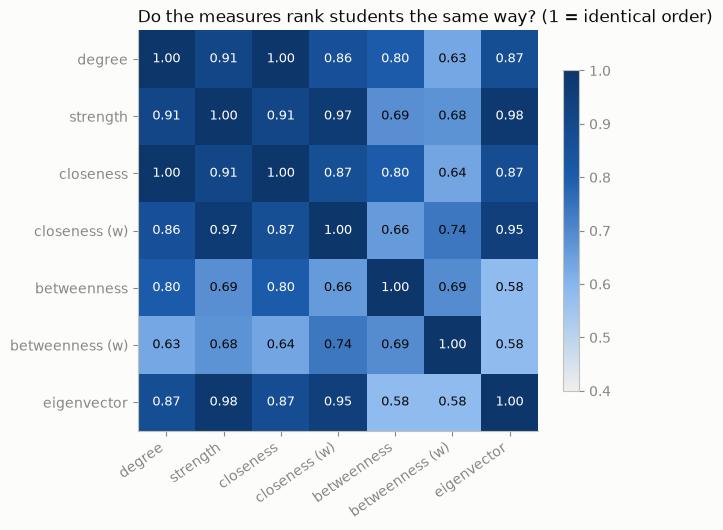

In [16]:
rank_corr = central[measures].corr(method="spearman")
fig, ax = plt.subplots(figsize=(6.5, 5.2))
im = ax.imshow(rank_corr.to_numpy(), cmap=seq, vmin=0.4, vmax=1)
ax.set_xticks(range(len(measures)), measures, rotation=35, ha="right")
ax.set_yticks(range(len(measures)), measures)
for a in range(len(measures)):
    for b in range(len(measures)):
        v = rank_corr.iloc[a, b]
        ax.text(b, a, f"{v:.2f}", ha="center", va="center", color="white" if v > 0.75 else INK, fontsize=9)
ax.grid(False)
ax.set_title("Do the measures rank students the same way? (1 = identical order)", loc="left")
fig.colorbar(im, ax=ax, shrink=0.8)
save(fig, "centrality_correlations.png")
plt.show()

The same measures again, on the top-2 network. Distances there are longer and more varied, so closeness and betweenness can tell students apart better than in the crowded full network. If the same names come back in both, the result isn't an artefact of how crowded the full network is.

In [17]:
# Same measures on the top-2 network, where distances vary more
Tc = largest_component(T)
central_sparse = pd.DataFrame({
    "degree": pd.Series(nx.degree_centrality(T)),
    "closeness": pd.Series(nx.closeness_centrality(T)),
    "betweenness": pd.Series(nx.betweenness_centrality(T)),
    "eigenvector": pd.Series(nx.eigenvector_centrality_numpy(Tc, weight="weight")),
})
print("Top 8 students by each measure in the top-2 network:")
print(pd.DataFrame({m: central_sparse[m].sort_values(ascending=False).index[:8].tolist()
                    for m in central_sparse}, index=[f"#{i}" for i in range(1, 9)]).to_string())

Top 8 students by each measure in the top-2 network:
   degree closeness betweenness eigenvector
#1     87        41          87         110
#2     41       104         104          94
#3    110        94          41          41
#4     94        87          77          21
#5     67        80          94          50
#6     81        38          91          81
#7     91        52         110         108
#8    104       110          38         105


The plot below checks the simplest possible explanation of total agreement (strength): that a student who agrees with more statements will, by construction, agree with more classmates.

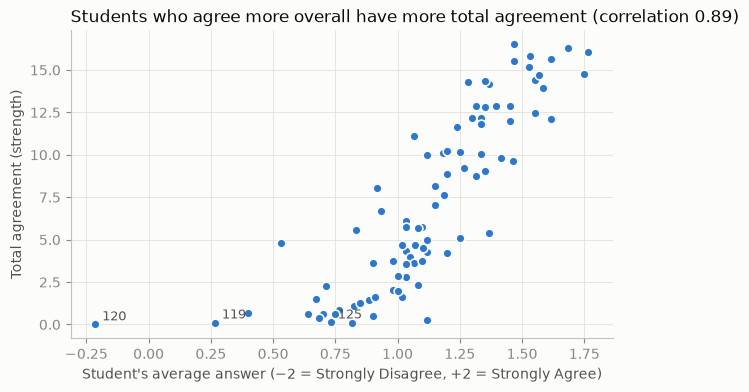

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(central["mean_answer"], central["strength"], s=40, color=BLUE,
           edgecolor=SURFACE, linewidth=1.2, zorder=3)
for s in central.sort_values("strength").index[:3]:
    ax.annotate(s, (central.loc[s, "mean_answer"], central.loc[s, "strength"]),
                xytext=(5, 3), textcoords="offset points", color=INK2, fontsize=9)
rho = central["mean_answer"].corr(central["strength"], method="spearman")
ax.set_xlabel("Student's average answer (−2 = Strongly Disagree, +2 = Strongly Agree)")
ax.set_ylabel("Total agreement (strength)")
ax.set_title(f"Students who agree more overall have more total agreement (correlation {rho:.2f})", loc="left")
save(fig, "strength_vs_mean_answer.png")
plt.show()

**What the centrality measures show.**
* **Two different kinds of "central" student.**
  * **Strength and eigenvector** rank highest the students who answered "Strongly Agree" to most statements (67, 110, 41, 114, 105, 83). Their edges are the *strongest*, and mostly with each other.
  * **Degree and closeness** rank a different set highest (52, 99, 101, 38, 53), who mix "Agree" and "Strongly Agree" about evenly. They have the *most* edges, and are the most "typical" students in the class.
  * Weighted closeness sides with strength, because short steps need strong edges.
* **Betweenness is led by 87 and 77**, who answered only the Technology section. Their scores rest on just 15 questions and are unreliable, so this is most likely a side-effect of missing answers rather than a real bridging role. The next names (101, 126, 99, 90, 70) answered plain "Agree" often, putting them between the emphatic students and the cautious ones.
* **The measures mostly agree, but not completely** (see the heatmap). Degree, closeness, strength and eigenvector give very similar rankings (correlation ≈ 0.85–1.0), as expected when the network is this crowded. **Betweenness differs the most** (≈ 0.6–0.8 with the others).
* **Students on the periphery.** The same students come last on every measure: 120 (no edges), 125, 119, 89, 22, 63. They have one to a few weak edges and never sit between others. Most have average answers well below the class average of +1.14.
* **In the top-2 network**, where each student keeps only their two strongest edges, the same emphatic answerers come back (41, 110, 94, 67, 81), so their central position isn't an artefact of the full network's crowding. Student 87 tops that list too, which is the same 15-answer problem as above.
* A student's total agreement (strength) closely follows their average answer (plot below), which is what we'd expect when most of the class agrees: a student who agrees with more statements agrees with more classmates.

## Two students who almost always said "Strongly Agree": 41 and 94

Students 41 and 94 answered "Strongly Agree" to more than 50 of the 60 statements. With the simple score, a student like that looks similar to everyone. The adjusted score should reduce this, because matching on questions everyone agrees on is worth little.

In [19]:
raw_strength = pd.Series(W_raw.sum(axis=1), index=students)
rank = pd.DataFrame({
    "rank by simple score": raw_strength.rank(ascending=False).astype(int),
    "rank by adjusted score": central["strength"].rank(ascending=False).astype(int),
    "share of answers Strongly Agree": (responses == 2).sum(axis=1) / responses.notna().sum(axis=1),
})
rank.loc[["41", "94"]].round(2)

,rank by simple score,rank by adjusted score,share of answers Strongly Agree
41,6,3,0.87
94,13,8,0.85


These two don't become the most connected students, but they stay near the top with **both** scores. That fits the finding above: in this class, strongly agreeing with most statements **is** the typical position, so it really does sit at the centre.

## One network per topic: do students line up the same way on every topic?

The survey has four sections of 15 statements each: Technology, Education, Society & Ethics, Environment. We rebuild the network four times, using only one section's questions each time (keeping students who answered at least 10 of them), and ask whether the same pairs of students agree in each topic.

Two comparisons, both without needing groups:
* **Pair scores:** take every pair of students and compare their adjusted score in topic A with their score in topic B (rank correlation). A high value means the pairs who agree on Technology are the same pairs who agree on Education.
* **Student strengths:** the same for total agreement per student. A high value means the students near the centre of one topic are near the centre of the other.

In [20]:
from scipy.stats import spearmanr

topic_scores, topic_stats = {}, []
for sec, name in SECTIONS.items():
    cols = [j for j, q in enumerate(questions) if q.startswith(sec)]
    keep = [i for i in range(N) if (~np.isnan(X[i, cols])).sum() >= 10]
    nodes = [students[i] for i in keep]
    _, W_sec, _ = agreement_weights(X[np.ix_(keep, cols)])
    G_sec = build_graph(W_sec, 0.0, nodes=nodes)
    topic_scores[sec] = (W_sec, {s: k for k, s in enumerate(nodes)})
    topic_stats.append({"topic": name, "students": len(nodes), "edges": G_sec.number_of_edges(),
                        "share of pairs linked": nx.density(G_sec),
                        "clustering": nx.average_clustering(G_sec),
                        "students with no edges": nx.number_of_isolates(G_sec)})
print(pd.DataFrame(topic_stats).round(3).to_string(index=False))

topics = list(SECTIONS)
pair_corr = pd.DataFrame(index=topics, columns=topics, dtype=float)
for a, b in itertools.combinations_with_replacement(topics, 2):
    Wa, ia = topic_scores[a]
    Wb, ib = topic_scores[b]
    shared = [s for s in ia if s in ib]
    va = [Wa[ia[x], ia[y]] for x, y in itertools.combinations(shared, 2)]
    vb = [Wb[ib[x], ib[y]] for x, y in itertools.combinations(shared, 2)]
    pair_corr.loc[a, b] = pair_corr.loc[b, a] = spearmanr(va, vb)[0]

topic_strength = pd.DataFrame({
    sec: pd.Series({s: np.clip(W[idx[s]], 0, None).sum() for s in idx})
    for sec, (W, idx) in topic_scores.items()})
strength_corr = topic_strength.corr(method="spearman")

print("\nHow similarly two topics score the same pair of students (rank correlation):")
print(pair_corr.round(2).to_string())
print("\nHow similarly two topics rank students by total agreement:")
print(strength_corr.round(2).to_string())

           topic  students  edges  share of pairs linked  clustering  students with no edges
      Technology        91   1969                  0.481       0.670                       1
       Education        87   1846                  0.493       0.674                       0
Society & Ethics        87   1809                  0.484       0.712                       5
     Environment        85   1894                  0.531       0.748                       4

How similarly two topics score the same pair of students (rank correlation):
      T     E     S     V
T  1.00  0.16  0.28  0.23
E  0.16  1.00  0.33  0.33
S  0.28  0.33  1.00  0.46
V  0.23  0.33  0.46  1.00

How similarly two topics rank students by total agreement:
      T     E     S     V
T  1.00  0.32  0.43  0.34
E  0.32  1.00  0.47  0.41
S  0.43  0.47  1.00  0.56
V  0.34  0.41  0.56  1.00


The same two tables as heatmaps, with the topics in survey order.

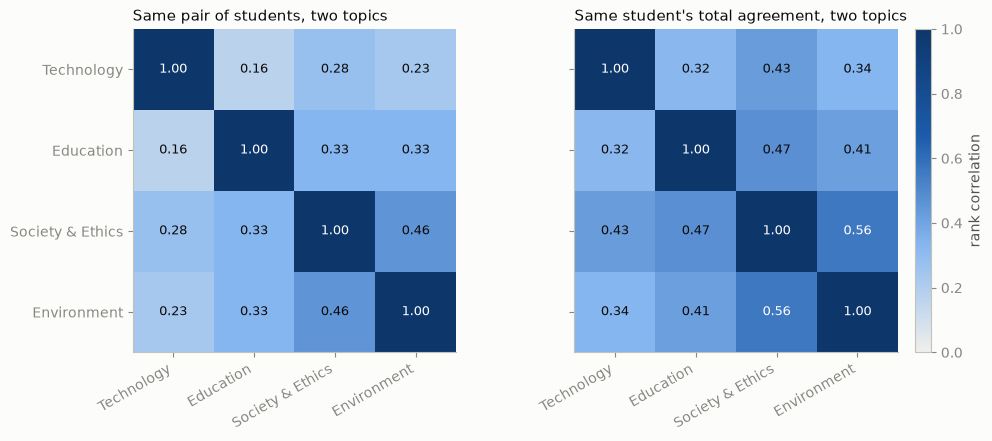

In [21]:
names = [SECTIONS[t] for t in topics]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, M, title in [(axes[0], pair_corr, "Same pair of students, two topics"),
                     (axes[1], strength_corr, "Same student's total agreement, two topics")]:
    im = ax.imshow(M.to_numpy(dtype=float), cmap=seq, vmin=0, vmax=1)
    ax.set_xticks(range(len(topics)), names, rotation=30, ha="right")
    ax.set_yticks(range(len(topics)), names if ax is axes[0] else [""] * len(topics))
    for a in range(len(topics)):
        for b in range(len(topics)):
            v = M.iloc[a, b]
            ax.text(b, a, f"{v:.2f}", ha="center", va="center",
                    color="white" if v > 0.55 else INK, fontsize=9)
    ax.grid(False)
    ax.set_title(title, loc="left", fontsize=11)
fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02, label="rank correlation")
save(fig, "topic_comparison.png")
plt.show()

**What the topic networks show.**
* **Each topic on its own produces a network much like the whole survey:** about half of all pairs linked, clustering 0.67–0.75.
* **Society and Environment line students up most alike** (pair scores correlate 0.46, strengths 0.56). A pair who agree above chance on social statements usually agree above chance on environmental ones too.
* **Technology and Education are the least alike** (0.16). Two students can agree closely about AI and not at all about teaching.
* **All the correlations are well below 1**, so which classmates a student agrees with genuinely depends on the topic. Agreement in this class is not one single attitude: it's topic by topic, with Society and Environment the most closely tied pair.

# Summary of Findings

1. **Counting matching answers isn't enough.** Because the class agrees with most statements, every pair of students looks similar and every student would be linked to every other. Adjusting for chance agreement gives a meaningful cutoff (more than chance) and a network where about half of all pairs are linked.
2. **Small-world pattern, with very uneven numbers of edges.** Students are about 1.5× more clustered than an ER graph in the full network and 6× in the top-2 network, while being about as close to each other as in an ER graph (σ ≈ 1.5 and 5.7). Degree varies far more than in an ER graph (spread 21 vs 4.6). Well-connected students show no preference for each other (assortativity ≈ 0).
3. **No sudden break-up.** Removing weak edges cuts students off one or a few at a time, so the class isn't a set of separate camps joined by a few weak links.
4. **Two kinds of central student.** Total agreement (strength) and eigenvector centrality are highest for the students who answered "Strongly Agree" to most statements. Degree and closeness are highest for "typical" students who mix "Agree" and "Strongly Agree". Betweenness gives the most different ranking, and its top names are unreliable because they answered only one section.
5. **A handful of students sit on the periphery** (120, 119, 125, 89, 22). Their average answers are well below the class average of +1.14, and student 120 (average below Neutral) has no above-chance edge with anyone.
6. **Centrality mostly reflects how much a student agrees overall.** Total agreement follows a student's average answer closely, which is what happens when the class agrees on most things.
7. **Agreement is topic-specific.** Society and Environment line students up most alike; Technology and Education least. No topic pair comes close to lining up identically.